In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("../data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

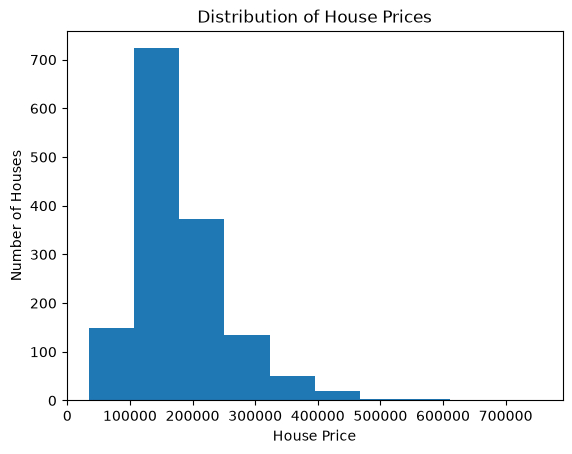

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["SalePrice"], bins=10)
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

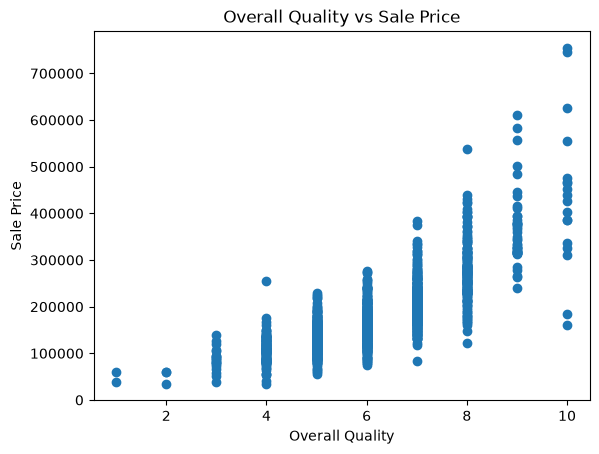

In [6]:
import matplotlib.pyplot as plt

# Create a scatter plot.
# X-axis = OverallQual (overall quality of the house)
# Y-axis = SalePrice (selling price of the house)
# Each dot represents ONE house in our dataset.
plt.scatter(df["OverallQual"], df["SalePrice"])

# Give the X-axis a name.
plt.xlabel("Overall Quality")

# Give the Y-axis a name.
plt.ylabel("Sale Price")

# Give the graph a title.
plt.title("Overall Quality vs Sale Price")

# Display the graph.
plt.show()

In [7]:
correlation=df["OverallQual"].corr(df["SalePrice"])
print(correlation)

0.7909816005838052


In [8]:
correlation = df.corr(numeric_only=True)
saleprice_corr = correlation["SalePrice"]
saleprice_corr = saleprice_corr.sort_values()
print(saleprice_corr)

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

In [9]:
saleprice_corr = df.corr(numeric_only=True)["SalePrice"]
strong_corr = saleprice_corr.abs().sort_values(ascending=False)
print(strong_corr.head(10))



SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [10]:
missing_values=df.isnull().sum()
print(missing_values[missing_values>0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [11]:
# Missing means the feature does not exist
# So replace NaN with "None"

categorical_none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

for col in categorical_none_cols:
    df[col] = df[col].fillna("None")

In [12]:
numeric_median_cols = [
    "LotFrontage",
    "MasVnrArea",
    "GarageYrBlt"
]

for col in numeric_median_cols:
    df[col]=df[col].fillna(df[col].median())


In [13]:
missing_values=df.isnull().sum()
print(missing_values[missing_values>0])

Electrical    1
dtype: int64


In [14]:
df["Electrical"]=df["Electrical"].fillna(df["Electrical"].mode()[0])

In [15]:
# X = input features used to predict house price
# We remove SalePrice because it is the answer we want to predict

X = df.drop("SalePrice", axis=1)

# y = target/output we want the model to predict
y = df["SalePrice"]

In [16]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [17]:
print(X_encoded.shape)

(1460, 260)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 260)
(292, 260)
(1168,)
(292,)


In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](260,)","[ 0.39, -88.96, -131.88,..., 6286.68, 7860.1 ,19030.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](260,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.471e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,260
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(241)


In [22]:
y_pred = model.predict(X_test)

In [23]:
print(y_pred[:5])

[159629.72400733 341514.91047082  82746.44771256 188232.74253018
 315808.89751166]


In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1106826200.9105847


In [26]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

In [27]:
print("RMSE:", rmse)

RMSE: 33268.997594015134


In [28]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 20291.079274939628


In [29]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.855700243899212


In [30]:
# Import StandardScaler from Scikit-learn.
# StandardScaler is used to put features with different numerical ranges
# onto a similar scale.
from sklearn.preprocessing import StandardScaler


# Create a StandardScaler object.
# Think of "scaler" as a tool that will learn how to scale our features.
scaler = StandardScaler()


# TRAINING DATA:
# fit_transform() does TWO things:
#
# 1. fit()      → learns the mean and standard deviation from X_train
# 2. transform() → uses them to scale X_train
#
# Example:
# Suppose OverallQual in X_train has:
# Mean = 6
# Standard deviation = 2
#
# If one house has OverallQual = 8:
#
# Scaled value = (8 - 6) / 2
#              = 1
#
# So 8 becomes 1 after scaling.
X_train_scaled = scaler.fit_transform(X_train)


# TEST DATA:
# Here we use ONLY transform().
#
# We DO NOT calculate a new mean and standard deviation from X_test.
# We use the SAME mean and standard deviation learned from X_train.
#
# Example:
# Training mean = 6
# Training standard deviation = 2
#
# Suppose a test house has OverallQual = 7:
#
# Scaled value = (7 - 6) / 2
#              = 0.5
#
# This keeps training and testing data on the SAME scaling system.
X_test_scaled = scaler.transform(X_test)





In [31]:
correlation_matrix = X_encoded.corr()
print(correlation_matrix)

                             Id  MSSubClass  LotFrontage   LotArea  \
Id                     1.000000    0.011156    -0.009921 -0.033226   
MSSubClass             0.011156    1.000000    -0.356718 -0.139781   
LotFrontage           -0.009921   -0.356718     1.000000  0.304522   
LotArea               -0.033226   -0.139781     0.304522  1.000000   
OverallQual           -0.028365    0.032628     0.234812  0.105806   
...                         ...         ...          ...       ...   
SaleCondition_AdjLand -0.034852    0.016241    -0.036570 -0.013208   
SaleCondition_Alloca  -0.009018    0.030002    -0.018040  0.008966   
SaleCondition_Family   0.004865    0.000983     0.016250 -0.010781   
SaleCondition_Normal   0.015881    0.024359    -0.074146  0.005711   
SaleCondition_Partial -0.020738   -0.051068     0.127293  0.022635   

                       OverallQual  OverallCond  YearBuilt  YearRemodAdd  \
Id                       -0.028365     0.012609  -0.012713     -0.021998   
MSSubCl

In [32]:
import numpy as np

# 1. Calculate feature-to-feature correlations
# abs() means we care about strength, whether + or -
corr_abs = X_encoded.corr().abs()

# 2. Keep only the upper half
# This removes duplicate pairs and self-correlation
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# 3. Convert the correlation table into a simple list
high_corr = upper.stack()

# 4. Keep only very strong correlations (> 0.80)
high_corr = high_corr[high_corr > 0.80]

# 5. Put strongest correlations first
high_corr = high_corr.sort_values(ascending=False)

# 6. Display them
print(high_corr)

BsmtCond_None        BsmtFinType1_None        1.000000
GarageType_None      GarageCond_None          1.000000
GarageQual_None      GarageCond_None          1.000000
GarageFinish_None    GarageCond_None          1.000000
                     GarageQual_None          1.000000
BsmtQual_None        BsmtCond_None            1.000000
                     BsmtFinType1_None        1.000000
Exterior1st_CBlock   Exterior2nd_CBlock       1.000000
GarageType_None      GarageFinish_None        1.000000
                     GarageQual_None          1.000000
PoolArea             PoolQC_None              0.989665
SaleType_New         SaleCondition_Partial    0.986819
BsmtCond_None        BsmtFinType2_None        0.986408
BsmtQual_None        BsmtFinType2_None        0.986408
BsmtFinType1_None    BsmtFinType2_None        0.986408
BsmtExposure_None    BsmtFinType1_None        0.986408
BsmtCond_None        BsmtExposure_None        0.986408
BsmtQual_None        BsmtExposure_None        0.986408
Exterior1s

In [33]:
# Import VIF function
# VIF helps us check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Select some important numerical features from X_train
# We are checking whether these features are too strongly related to each other
vif_features = X_train[
    [
        "OverallQual",
        "GrLivArea",
        "GarageCars",
        "GarageArea",
        "TotalBsmtSF",
        "1stFlrSF",
        "FullBath",
        "TotRmsAbvGrd",
        "YearBuilt"
    ]
]


# Create an empty DataFrame
# We will store Feature name and VIF value here
vif_data = pd.DataFrame()


# Put all selected feature names into a column called "Feature"
# Example:
# GarageCars
# GarageArea
# OverallQual
vif_data["Feature"] = vif_features.columns


# Calculate VIF for every feature
#
# vif_features.values
# → gives the numerical values of all selected features
#
# i
# → tells Python which feature we are calculating VIF for
#
# Example:
# i = 0 → calculate VIF for OverallQual
# i = 1 → calculate VIF for GrLivArea
# i = 2 → calculate VIF for GarageCars
#
# range(vif_features.shape[1])
# → repeat for all selected columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]


# Sort VIF from highest to lowest
# Highest VIF comes first
vif_data = vif_data.sort_values("VIF", ascending=False)


# Show the final table
print(vif_data)






        Feature       VIF
2    GarageCars  5.231610
3    GarageArea  4.971342
1     GrLivArea  4.962533
5      1stFlrSF  3.800568
4   TotalBsmtSF  3.779194
7  TotRmsAbvGrd  3.308692
0   OverallQual  2.488163
6      FullBath  2.168765
8     YearBuilt  2.102352


In [34]:
# Show the intercept learned by the model
print("Intercept:", model.intercept_)

# Show the coefficients learned for all features
print("Coefficients:", model.coef_)

Intercept: 447071.2746923994
Coefficients: [ 3.87395531e-01 -8.89637209e+01 -1.31875132e+02  6.70631462e-01
  7.09789590e+03  5.50271526e+03  2.99538583e+02  7.19742752e+01
  2.56910923e+01  7.80159952e+00  5.13845113e+00 -7.69716619e-01
  1.21703310e+01  1.26645827e+01  2.81729909e+01 -1.79631311e+01
  2.28744402e+01  2.89813082e+03 -2.37388438e+03  5.09521170e+03
  2.60155335e+03 -1.37769320e+03 -1.04498319e+04  3.18891136e+03
  6.66735259e+03 -3.68015696e+01  8.62230375e+03  1.23901276e+01
  1.98166751e+01  1.15572503e+01 -1.88181264e+00  6.14569447e+01
  4.47101287e+01  2.84460648e+02  1.56462139e+00 -2.93385256e+02
 -5.91754716e+02  3.53184057e+04  2.48572747e+04  2.62824406e+04
  2.50609597e+04  2.28365270e+04 -1.16750659e+03  2.83236656e+03
  9.23641891e+03 -6.20409743e+03  4.65224447e+02  2.22980825e+04
  2.59596999e+03  1.29599770e+04 -5.14672189e+04  1.07921845e+04
 -8.38283951e+03 -2.22989207e+04 -1.10936037e+03  6.69364075e+03
 -3.35704469e+04 -8.57702731e+03 -5.29832375e+0

In [35]:
coef_table = pd.DataFrame({
    "Feature": X_encoded.columns,

    "Coefficient": model.coef_
})

print(coef_table.head(10))

        Feature  Coefficient
0            Id     0.387396
1    MSSubClass   -88.963721
2   LotFrontage  -131.875132
3       LotArea     0.670631
4   OverallQual  7097.895904
5   OverallCond  5502.715258
6     YearBuilt   299.538583
7  YearRemodAdd    71.974275
8    MasVnrArea    25.691092
9    BsmtFinSF1     7.801600


In [36]:
#Linear Regression FROM SCRATCH USING NUMPY + Gradient Descent
import numpy as np

X_train_np = np.array(X_train_scaled, dtype=float)
X_test_np = np.array(X_test_scaled, dtype=float)

y_train_np = np.array(y_train, dtype=float)
y_test_np = np.array(y_test, dtype=float)

n_samples, n_features = X_train_np.shape

weights = np.zeros(n_features)
bias = 0.0

learning_rate = 0.01
iterations = 2000

for i in range(iterations):
    y_pred_train = X_train_np @ weights + bias

    errors = y_pred_train - y_train_np

    mse = np.mean(errors ** 2)

    dw = (2 / n_samples) * (X_train_np.T @ errors)
    db = (2 / n_samples) * np.sum(errors)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    if i % 200 == 0:
        print("Iteration:", i, "MSE:", mse)

print("\nTraining completed!")

print("Learned bias:", bias)
print("Number of learned weights:", len(weights))

y_pred_scratch = X_test_np @ weights + bias

print("\nFirst 5 scratch-model predictions:")
print(y_pred_scratch[:5])

test_errors = y_pred_scratch - y_test_np

mae_scratch = np.mean(np.abs(test_errors))

mse_scratch = np.mean(test_errors ** 2)

rmse_scratch = np.sqrt(mse_scratch)

ss_res = np.sum((y_test_np - y_pred_scratch) ** 2)

mean_price = np.mean(y_test_np)

ss_total = np.sum((y_test_np - mean_price) ** 2)

r2_scratch = 1 - (ss_res / ss_total)

print("\n----- NUMPY SCRATCH MODEL RESULTS -----")

print("MAE:", mae_scratch)
print("MSE:", mse_scratch)
print("RMSE:", rmse_scratch)
print("R²:", r2_scratch)



Iteration: 0 MSE: 38885583525.70976
Iteration: 200 MSE: 535347298.15473205
Iteration: 400 MSE: 483390060.4738199
Iteration: 600 MSE: 464791215.4579452
Iteration: 800 MSE: 453283639.35606194
Iteration: 1000 MSE: 445001572.78166
Iteration: 1200 MSE: 438483799.94582075
Iteration: 1400 MSE: 433057681.1374886
Iteration: 1600 MSE: 428374711.20454687
Iteration: 1800 MSE: 424237830.0433324

Training completed!
Learned bias: 181441.54195205416
Number of learned weights: 260

First 5 scratch-model predictions:
[159753.74513938 342484.76955387  85539.04002561 186071.61061533
 322559.99757704]

----- NUMPY SCRATCH MODEL RESULTS -----
MAE: 19830.209333084065
MSE: 1123991638.150152
RMSE: 33525.98452171318
R²: 0.8534623420452487


In [37]:
# Create a table with actual price, predicted price, and error
error_analysis = pd.DataFrame({
    "Actual": y_test_np,
    "Predicted": y_pred_scratch
})

# Absolute error for each house
error_analysis["Error"] = abs(
    error_analysis["Actual"] - error_analysis["Predicted"]
)

# Show biggest mistakes first
error_analysis = error_analysis.sort_values(
    "Error",
    ascending=False
)

print(error_analysis.head(10))


       Actual      Predicted          Error
193  171000.0  -58027.618935  229027.618935
214  241500.0   43335.124052  198164.875948
139  755000.0  584848.936956  170151.063044
74   611657.0  456864.714464  154792.285536
168  556581.0  429085.192757  127495.807243
43   253293.0  359016.485699  105723.485699
260  395000.0  296848.566153   98151.433847
278  143000.0  226627.099830   83627.099830
152  200624.0  281763.512990   81139.512990
181   55993.0  134496.180631   78503.180631


In [38]:
print("Kernel working")

Kernel working
